#**Scenario 1**
---
##**TL-MobileNetV2 - Optimizer Adam - Learning Rate 0.001 - Tanpa Object Cropping Dataset**

###**Import Dataset**

In [ ]:
#--- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#--- Import Dataset ---
dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/dataset/final_dataset_ori' # lokasi dataset

import os
if os.path.exists(dataset_path):
    print("Dataset ditemukan di:", dataset_path)
else:
    print("Folder dataset tidak ditemukan, cek kembali path-nya.")

Dataset ditemukan di: /content/drive/MyDrive/SKRIPSI/dataset/dataset/final_dataset_ori


In [ ]:
#--- Cek Jumlah Data Per Kelas ---
import os

dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/dataset/final_dataset_ori' # lokasi dataset

total_files = 0

print("Jumlah data per kelas:\n")

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith('.jpg')
        ]
        num_files = len(files)
        total_files += num_files

        print(f"{class_name}: {num_files} data")

print("\nTotal seluruh data:", total_files)

Jumlah data per kelas:

pisang susu: 400 data
pisang embug: 400 data
pisang mas: 400 data
pisang candi: 400 data
pisang cavendish: 400 data
pisang barlin: 400 data
pisang ambon: 400 data
pisang agung: 400 data

Total seluruh data: 3200


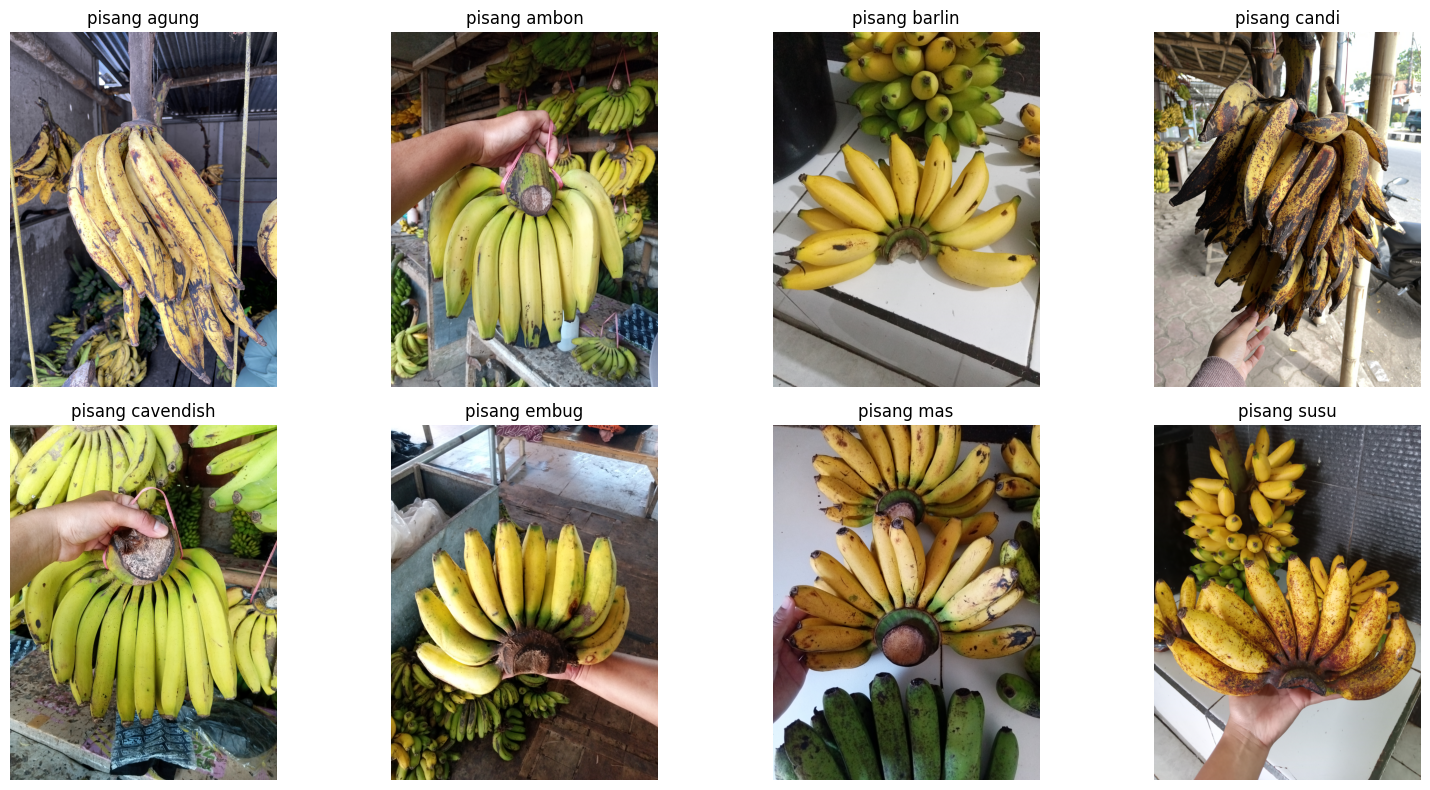

In [ ]:
#--- Display Dataset ---
import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/dataset/final_dataset_ori' # lokasi dataset

# Ambil daftar kelas (subfolder)
classes = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
])

# Setup figure: 2 baris x 4 kolom
plt.figure(figsize=(16, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    # Ambil satu gambar pertama dari kelas tersebut
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith('.jpg')
    ]

    if len(images) == 0:
        continue

    img_path = os.path.join(class_path, images[0])
    img = Image.open(img_path)

    # Plot
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

###**Split Dataset 80:20 (train:val)**

In [ ]:
#--- Split Dataset 80:20 (train:val) ---
import os
import shutil
import random

# Path dataset asli
dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/dataset/final_dataset_ori' # lokasi dataset

# Path output split
output_path = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_ori' # lokasi dataset yang sudah di split
train_path = os.path.join(output_path, 'train')
test_path = os.path.join(output_path, 'val')

# Buat folder train & test jika belum ada
os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

# Seed agar hasil split konsisten
random.seed(42)

# Loop setiap kelas
for class_name in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_dir):
        continue

    # Ambil semua file gambar
    images = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith('.jpg')
    ]

    random.shuffle(images)

    # Hitung jumlah train (80%)
    split_idx = int(0.8 * len(images))
    train_images = images[:split_idx]
    test_images = images[split_idx:]

    # Buat folder kelas
    os.makedirs(os.path.join(train_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_path, class_name), exist_ok=True)

    # Copy file ke folder train
    for img in train_images:
        shutil.copy(
            os.path.join(class_dir, img),
            os.path.join(train_path, class_name, img)
        )

    # Copy file ke folder val
    for img in test_images:
        shutil.copy(
            os.path.join(class_dir, img),
            os.path.join(test_path, class_name, img)
        )

    print(f"{class_name}: {len(train_images)} train | {len(test_images)} val")

print("\n Split dataset selesai (80% train, 20% test)")

pisang susu: 320 train | 80 test
pisang embug: 320 train | 80 test
pisang mas: 320 train | 80 test
pisang candi: 320 train | 80 test
pisang cavendish: 320 train | 80 test
pisang barlin: 320 train | 80 test
pisang ambon: 320 train | 80 test
pisang agung: 320 train | 80 test

 Split dataset selesai (80% train, 20% test)


In [ ]:
#-- Cek Jumlah Dataset --
import os

dataset_split_path = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_ori'
train_path = os.path.join(dataset_split_path, 'train')
test_path  = os.path.join(dataset_split_path, 'test')

def count_images_per_class(path):
    class_counts = {}
    for class_name in sorted(os.listdir(path)):
        class_dir = os.path.join(path, class_name)
        if os.path.isdir(class_dir):
            images = [
                f for f in os.listdir(class_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]
            class_counts[class_name] = len(images)
    return class_counts

# Hitung jumlah data
train_counts = count_images_per_class(train_path)
test_counts  = count_images_per_class(test_path)

# Tampilkan hasil
print("📊 Jumlah data TRAIN per kelas:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\n📊 Jumlah data TEST per kelas:")
for cls, count in test_counts.items():
    print(f"{cls}: {count}")

print("\nTotal TRAIN:", sum(train_counts.values()))
print("Total TEST :", sum(test_counts.values()))

📊 Jumlah data TRAIN per kelas:
pisang agung: 320
pisang ambon: 320
pisang barlin: 320
pisang candi: 320
pisang cavendish: 320
pisang embug: 320
pisang mas: 320
pisang susu: 320

📊 Jumlah data TEST per kelas:
pisang agung: 80
pisang ambon: 80
pisang barlin: 80
pisang candi: 80
pisang cavendish: 80
pisang embug: 80
pisang mas: 80
pisang susu: 80

Total TRAIN: 2560
Total TEST : 640


###**Import Dataset Split**

In [ ]:
#-- Import Dataset Split --
dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_ori' # lokasi dataset

import os
if os.path.exists(dataset_path):
    print("Dataset ditemukan di:", dataset_path)
else:
    print("Folder dataset tidak ditemukan, cek kembali path-nya.")

Dataset ditemukan di: /content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_ori


In [ ]:
#-- Cek Jumlah Dataset --
import os

dataset_split_path = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_ori'
train_path = os.path.join(dataset_split_path, 'train')
test_path  = os.path.join(dataset_split_path, 'val')

def count_images_per_class(path):
    class_counts = {}
    for class_name in sorted(os.listdir(path)):
        class_dir = os.path.join(path, class_name)
        if os.path.isdir(class_dir):
            images = [
                f for f in os.listdir(class_dir)
                if f.lower().endswith('.jpg')
            ]
            class_counts[class_name] = len(images)
    return class_counts

# Hitung jumlah data
train_counts = count_images_per_class(train_path)
test_counts  = count_images_per_class(test_path)

# Tampilkan hasil
print("📊 Jumlah data TRAIN per kelas:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\n📊 Jumlah data VAL per kelas:")
for cls, count in test_counts.items():
    print(f"{cls}: {count}")

print("\nTotal TRAIN:", sum(train_counts.values()))
print("Total VAL :", sum(test_counts.values()))

📊 Jumlah data TRAIN per kelas:
pisang agung: 320
pisang ambon: 320
pisang barlin: 320
pisang candi: 320
pisang cavendish: 320
pisang embug: 320
pisang mas: 320
pisang susu: 320

📊 Jumlah data VAL per kelas:
pisang agung: 80
pisang ambon: 80
pisang barlin: 80
pisang candi: 80
pisang cavendish: 80
pisang embug: 80
pisang mas: 80
pisang susu: 80

Total TRAIN: 2560
Total VAL : 640


###**Preprocessing Dataset**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, AveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
train_dir = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_ori/train'
test_dir  = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_ori/val'

In [ ]:
#-- Preprocessing Dataset --
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input #-- Normalisasi [-1, 1]
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2560 images belonging to 8 classes.
Found 640 images belonging to 8 classes.


###**Pemodelan Arsitektur MobileNetV2**

In [ ]:
#--- Load MobileNetV2 (Pretrained ImageNet) ---
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze semua layer base model
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#-- Penambahan Head Custom Layer --

# Tambahkan custom classifier di akhir
x = base_model.output
x = AveragePooling2D(pool_size=(7, 7))(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(8, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

###**Compile dengan Optimizer Adam dan Learning Rate 0.001**

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,976 (9.87 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

###**Training Model**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    min_delta=0.001,
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

# Simpan Model Terbaik
checkpoint = ModelCheckpoint(
    'best_model_mobilenetv2.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

In [ ]:
#--- Training model ---
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1123s 14s/step - accuracy: 0.6267 - loss: 1.1082 - val_accuracy: 0.9859 - val_loss: 0.0814
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 580s 7s/step - accuracy: 0.9583 - loss: 0.1406 - val_accuracy: 0.9937 - val_loss: 0.0338
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 542s 7s/step - accuracy: 0.9794 - loss: 0.0872 - val_accuracy: 0.9922 - val_loss: 0.0332
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 564s 7s/step - accuracy: 0.9900 - loss: 0.0452 - val_accuracy: 0.9937 - val_loss: 0.0236
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 547s 7s/step - accuracy: 0.9874 - loss: 0.0428 - val_accuracy: 0.9953 - val_loss: 0.0161
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 550s 7s/step - accuracy: 0.9871 - loss: 0.0409 - val_accuracy: 0.9937 - val_loss: 0.0245
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 584s 7s/step - accuracy: 0.9967 - loss: 0.0149 - val_accuracy: 0.9984 - val_loss: 0.0080
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 567s 7s/step - accuracy: 0.9979 - loss: 0.0153 - val_accuracy: 

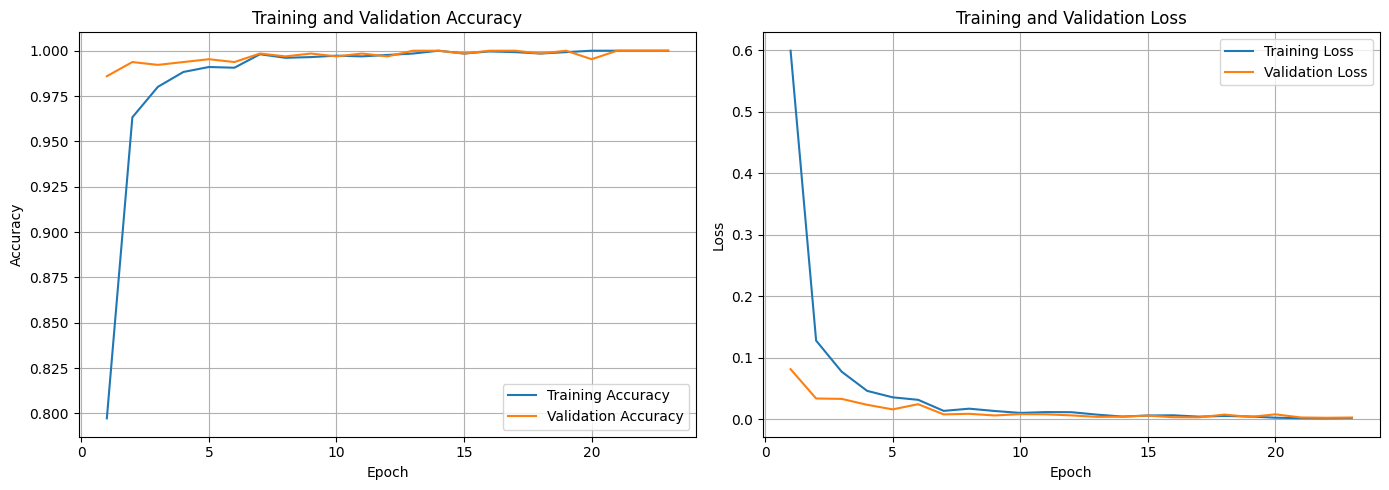

In [ ]:
#-- Menampilkan Grafik Akurasi dan Loss --
import matplotlib.pyplot as plt

# Ambil data dari history
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(accuracy) + 1)

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

###**Confussion Matrix**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Prediksi kelas
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Label sebenarnya
y_true = test_generator.classes

# Nama kelas
class_names = list(test_generator.class_indices.keys())

20/20 ━━━━━━━━━━━━━━━━━━━━ 109s 5s/step


In [ ]:
cm = confusion_matrix(y_true, y_pred)

<Figure size 800x800 with 0 Axes>

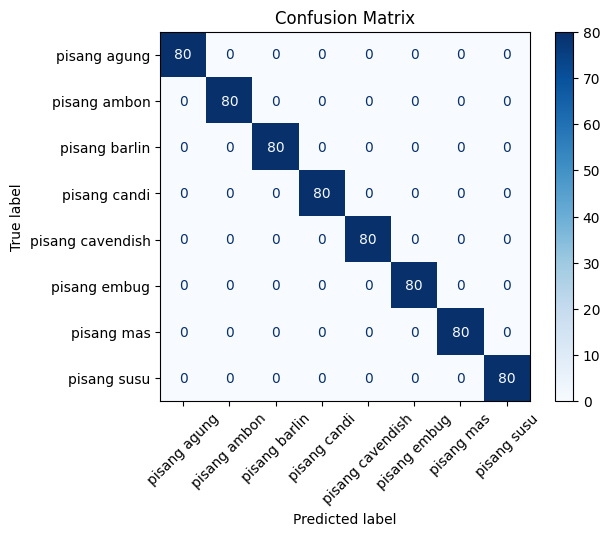

In [ ]:
plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

###**Precision, Recall, dan F1-Score**

In [ ]:
from sklearn.metrics import classification_report

# Tampilkan classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)

Classification Report:

                  precision    recall  f1-score   support

    pisang agung     1.0000    1.0000    1.0000        80
    pisang ambon     1.0000    1.0000    1.0000        80
   pisang barlin     1.0000    1.0000    1.0000        80
    pisang candi     1.0000    1.0000    1.0000        80
pisang cavendish     1.0000    1.0000    1.0000        80
    pisang embug     1.0000    1.0000    1.0000        80
      pisang mas     1.0000    1.0000    1.0000        80
     pisang susu     1.0000    1.0000    1.0000        80

        accuracy                         1.0000       640
       macro avg     1.0000    1.0000    1.0000       640
    weighted avg     1.0000    1.0000    1.0000       640



#**Heatmap**

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
#--- Load & Pre-process Image ---
def load_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img, img_array

In [ ]:
#--- Grad-CAM ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
#--- Overlay Heatmap ---
def overlay_heatmap(heatmap, original_img, alpha=0.4):
    heatmap = cv2.resize(
        heatmap,
        (original_img.size[0], original_img.size[1])
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original_img = np.array(original_img)
    superimposed_img = heatmap * alpha + original_img

    return np.uint8(superimposed_img)

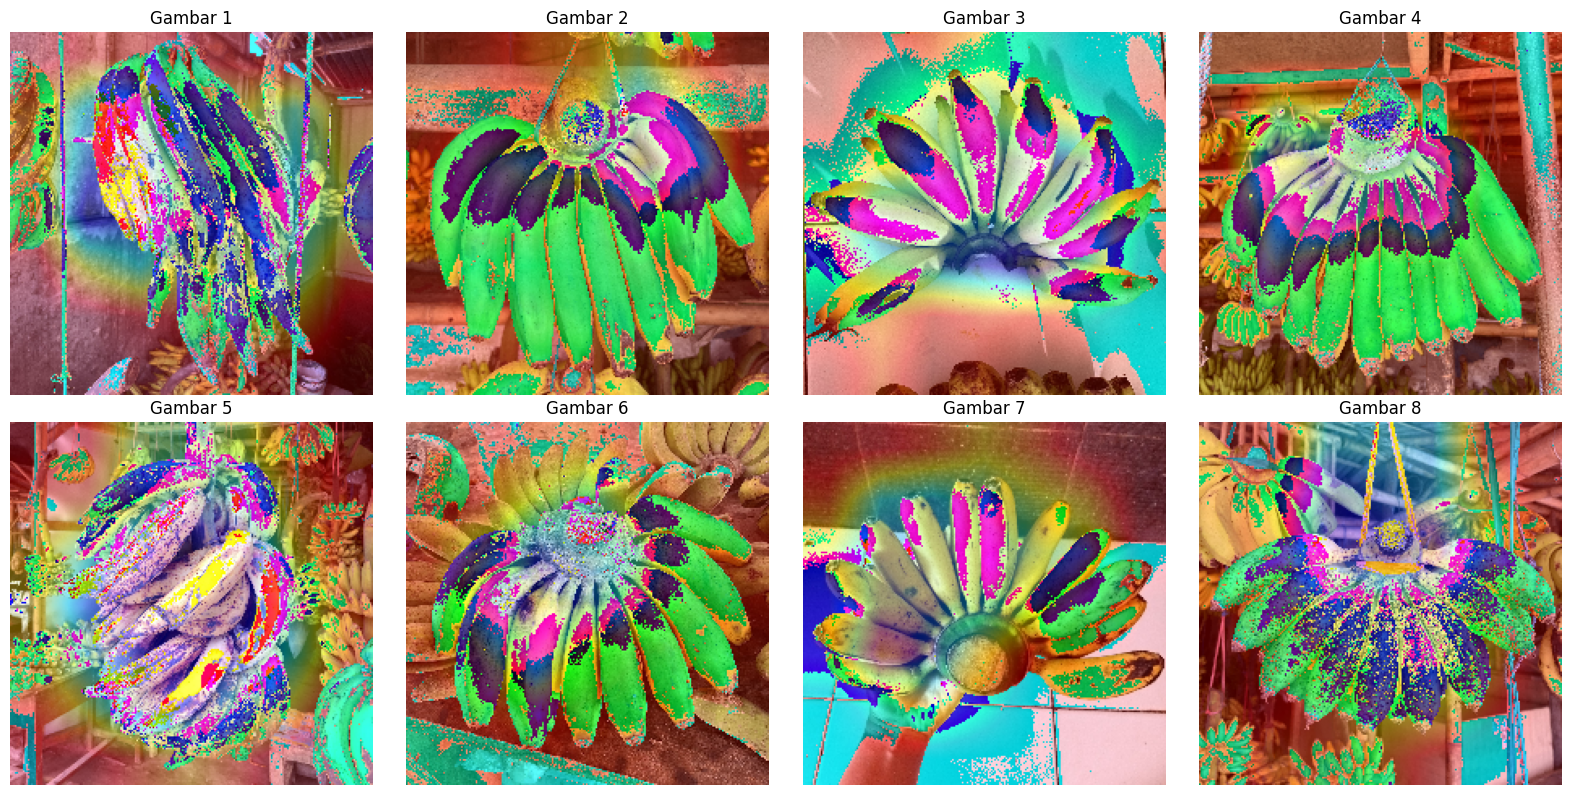

In [ ]:
import matplotlib.pyplot as plt

# Image Paths (8 citra)
img_paths = [
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/pisang agung.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/pisang ambon.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/pisang barlin.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/pisang cavendish.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/pisang candi.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/pisang embug.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/pisang mas.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/pisang susu.jpg"
]

# Nama layer konvolusi terakhir
last_conv_layer_name = "out_relu"

plt.figure(figsize=(16, 8))

for i, img_path in enumerate(img_paths):
    # Load 1 image
    original_img, img_array = load_image(img_path)

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    # Overlay heatmap ke gambar asli
    superimposed_img = overlay_heatmap(heatmap, original_img)

    # Tampilkan
    plt.subplot(2, 4, i + 1)
    plt.imshow(superimposed_img)
    plt.axis("off")
    plt.title(f"Gambar {i+1}")

plt.tight_layout()
plt.show()


#**Save Best Model .h5**

In [ ]:
model.save('S1_TL-MobileNetV2.h5')
print("Model successfully saved S1_TL-MobileNetV2.h5")

Model successfully saved S1_TL-MobileNetV2.h5


#**Preprocessing Input Images and Prediction**

In [1]:
#--- Import Model .h5 ---
from google.colab import files
uploaded = files.upload()

Saving best_model1_tl-mobilenetv2.h5 to best_model1_tl-mobilenetv2.h5


Saving pisang agung.jpg to pisang agung (2).jpg
Saving pisang ambon.jpg to pisang ambon (2).jpg
Saving pisang barlin.jpg to pisang barlin (2).jpg
Saving pisang candi.jpg to pisang candi (2).jpg
Saving pisang cavendish.jpg to pisang cavendish (2).jpg
Saving pisang embug.jpg to pisang embug (2).jpg
Saving pisang mas.jpg to pisang mas (2).jpg
Saving pisang susu.jpg to pisang susu (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 994ms/step

Image : pisang agung (2).jpg
=== HASIL PREDIKSI ===
pisang_agung: 100.00%
pisang_ambon: 0.00%
pisang_barlin: 0.00%
pisang_candi: 0.00%
pisang_cavendish: 0.00%
pisang_embug: 0.00%
pisang_mas: 0.00%
pisang_susu: 0.00%

Prediksi Akhir : pisang_agung
Confidence     : 100.00%


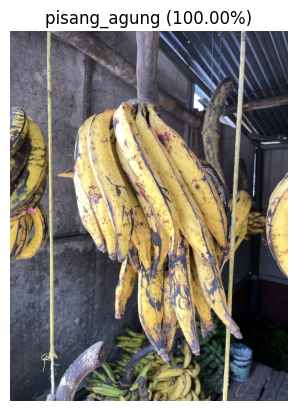

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

Image : pisang ambon (2).jpg
=== HASIL PREDIKSI ===
pisang_agung: 0.00%
pisang_ambon: 100.00%
pisang_barlin: 0.00%
pisang_candi: 0.00%
pisang_cavendish: 0.00%
pisang_embug: 0.00%
pisang_mas: 0.00%
pisang_susu: 0.00%

Prediksi Akhir : pisang_ambon
Confidence     : 100.00%


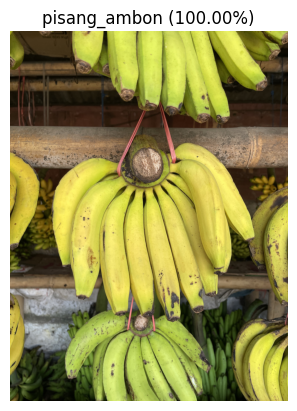

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

Image : pisang barlin (2).jpg
=== HASIL PREDIKSI ===
pisang_agung: 0.00%
pisang_ambon: 0.00%
pisang_barlin: 100.00%
pisang_candi: 0.00%
pisang_cavendish: 0.00%
pisang_embug: 0.00%
pisang_mas: 0.00%
pisang_susu: 0.00%

Prediksi Akhir : pisang_barlin
Confidence     : 100.00%


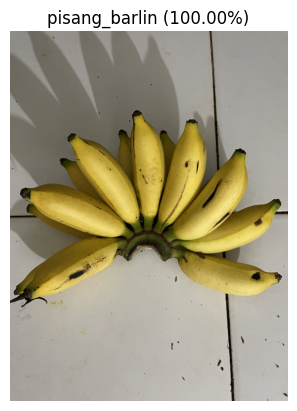

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

Image : pisang candi (2).jpg
=== HASIL PREDIKSI ===
pisang_agung: 0.13%
pisang_ambon: 0.00%
pisang_barlin: 0.00%
pisang_candi: 99.87%
pisang_cavendish: 0.00%
pisang_embug: 0.00%
pisang_mas: 0.00%
pisang_susu: 0.00%

Prediksi Akhir : pisang_candi
Confidence     : 99.87%


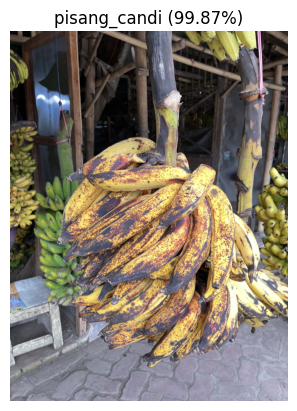

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Image : pisang cavendish (2).jpg
=== HASIL PREDIKSI ===
pisang_agung: 0.00%
pisang_ambon: 0.18%
pisang_barlin: 0.00%
pisang_candi: 0.00%
pisang_cavendish: 99.82%
pisang_embug: 0.00%
pisang_mas: 0.00%
pisang_susu: 0.00%

Prediksi Akhir : pisang_cavendish
Confidence     : 99.82%


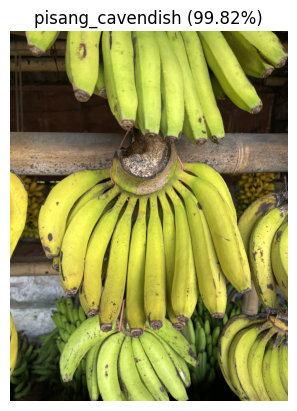

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Image : pisang embug (2).jpg
=== HASIL PREDIKSI ===
pisang_agung: 0.11%
pisang_ambon: 0.09%
pisang_barlin: 0.00%
pisang_candi: 0.00%
pisang_cavendish: 0.00%
pisang_embug: 99.80%
pisang_mas: 0.00%
pisang_susu: 0.00%

Prediksi Akhir : pisang_embug
Confidence     : 99.80%


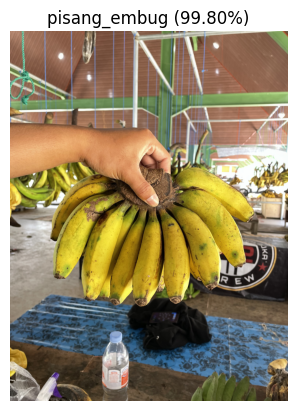

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

Image : pisang mas (2).jpg
=== HASIL PREDIKSI ===
pisang_agung: 0.00%
pisang_ambon: 0.00%
pisang_barlin: 0.03%
pisang_candi: 0.00%
pisang_cavendish: 0.00%
pisang_embug: 0.00%
pisang_mas: 99.97%
pisang_susu: 0.00%

Prediksi Akhir : pisang_mas
Confidence     : 99.97%


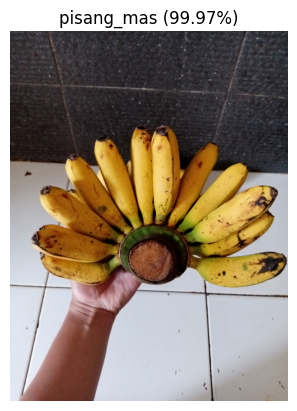

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

Image : pisang susu (2).jpg
=== HASIL PREDIKSI ===
pisang_agung: 0.31%
pisang_ambon: 0.00%
pisang_barlin: 0.00%
pisang_candi: 0.01%
pisang_cavendish: 0.06%
pisang_embug: 0.15%
pisang_mas: 0.00%
pisang_susu: 99.46%

Prediksi Akhir : pisang_susu
Confidence     : 99.46%


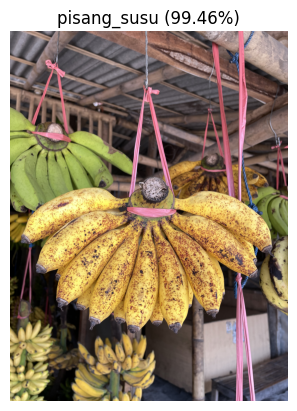

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

#--- Upload Multiple Images ---
def upload_images():
    uploaded = files.upload()
    image_paths = list(uploaded.keys())
    return image_paths

#--- Preprocess Image ---
def preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

#--- Predict Image ---
def predict_image(model, image_array, class_names):
    predictions = model.predict(image_array)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions)
    return predictions[0], predicted_class, confidence

#--- Class Names ---
class_names = [
    'pisang_agung',
    'pisang_ambon',
    'pisang_barlin',
    'pisang_candi',
    'pisang_cavendish',
    'pisang_embug',
    'pisang_mas',
    'pisang_susu'
]

#--- Load Model ---
model_path = '/content/best_model1_tl-mobilenetv2.h5'
model = tf.keras.models.load_model(model_path)

#--- Upload Images ---
image_paths = upload_images()

#--- Loop Prediction ---
for image_path in image_paths:

    image_array = preprocess_image(image_path)
    predictions, predicted_class, confidence = predict_image(
        model, image_array, class_names
    )

    print("\n==============================")
    print(f"Image : {image_path}")
    print("=== HASIL PREDIKSI ===")

    for i, class_name in enumerate(class_names):
        print(f"{class_name}: {predictions[i] * 100:.2f}%")

    print(f"\nPrediksi Akhir : {predicted_class}")
    print(f"Confidence     : {confidence * 100:.2f}%")

    #--- Display Image ---
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(f"{predicted_class} ({confidence * 100:.2f}%)")
    plt.axis('off')
    plt.show()